In [ ]:
#板块轮动统计打分
# 所有A股,剔除ST,停牌,上市不足半年的
# 针对个股计算指标，N日价格涨幅
# group by 板块，给板块热度打分，排序
# 展示给定日期最热门板块，板块内涨幅靠前个股，绘制板块历史热度情况
# 风险及免责提示：该策略由聚宽用户在聚宽社区分享，仅供学习交流使用。
# 原文一般包含策略说明，如有疑问请到原文和作者交流讨论。
# 原文网址：https://www.joinquant.com/view/community/detail/28005
# 标题：板块轮动打分与热度追踪

In [ ]:
#"sw_l1": 申万一级行业
#"sw_l2": 申万二级行业
#"sw_l3": 申万三级行业
#"jq_l1": 聚宽一级行业
#"jq_l2": 聚宽二级行业
#"zjw": 证监会行业
import jq_compat as jq
import pandas as pd
import numpy as np
from datetime import datetime,date,timedelta
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 10)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', -1)
import time
def time_me(fn):
    def _wrapper(*args, **kwargs):
        start = time.clock()
        ret=fn(*args, **kwargs)
        print("%s cost %s second"%(fn.__name__, time.clock() - start))
        return ret
    return _wrapper

In [ ]:
import pandas as pd
from datetime import datetime,date,timedelta

@time_me
def stock_industry(date,industry_category_list):
    """
    获得指定日期所有股票的行业分类
    :param date:
    :param industry_category_list: ['jq_l1','jq_l2','sw_l1','sw_l2','sw_l3','zjw']  聚宽1级，聚宽2级，申万1级，申万2级，申万3级，证监会行业
    :return:
    """
    # 过滤新股
    dt=datetime.strptime(date,'%Y-%m-%d')
    df = jq.get_all_securities(types=['stock'], date=date)
    df = df[df['start_date'] < (dt - timedelta(days=180)).date()]
    # 过滤ST股
    df_st_stock = jq.get_extras('is_st', list(df.index), end_date=date, count=1).reset_index(drop=True).T
    stock_list = list(df_st_stock[df_st_stock[0] == False].index)
    df_sec = df[df.index.isin(stock_list)]
    ind=jq.get_industry(list(df_sec.index),date=date)
    ind_dict={k:[ind[k][icode]['industry_name'] for icode in industry_category_list if len(set(ind[k].keys()).intersection(set(industry_category_list)))==len(industry_category_list)] for k in ind}
    df_ind=pd.DataFrame.from_dict(ind_dict, orient='index',
                       columns=[code for code in industry_category_list])
    df_ret = pd.merge(df_sec,df_ind,left_index=True,right_index=True,how='left')
    #print(len(df[df.isnull().T.any()]))
    return df_ret


def stock_industry_df(date,industry_category_list,df_stock):
    """
    获取给定股票列表，指定日期的行业分类
    :param date:
    :param industry_category_list: ['jq_l1','jq_l2','sw_l1','sw_l2','sw_l3','zjw']  聚宽1级，聚宽2级，申万1级，申万2级，申万3级，证监会行业
    :param df_stock: 股票dataframe index是股票代码
    :return:
    """
    ind = jq.get_industry(df_stock.index, date=date)
    ind_dict = {k: [ind[k][industry_category]['industry_name'] for industry_category in industry_category_list if
                    len(set(ind[k].keys()).intersection(set(industry_category_list))) == len(industry_category_list)]
                for k in ind}
    df_ind = pd.DataFrame.from_dict(ind_dict, orient='index',
                                    columns=[code for code in industry_category_list])
    df = pd.merge(df_stock, df_ind, left_index=True, right_index=True, how='left')
    return df

@time_me
def returns(stock_df,date,days):
    """
    计算N日收益率
    :param stock_df:
    :param date: 2020-01-01
    :param days: 5
    :return: 输入的DataFrame
    """
    panel = jq.get_price(list(stock_df.index), end_date=date, frequency='daily', fields=['close'], adjust='qfq', count=days+1)
    df_close = panel.set_index('date')['close'] if 'date' in panel.columns else panel['close']
    # 可以修改收益率计算公式改变排名规则
    series_return = (df_close.iloc[-1] / df_close.iloc[-days-1])-1
    stock_df['return']=series_return
    return stock_df

@time_me
def returns_series(stock_df,date,days,back_days):
    """
    计算连续back_days天的days日收益率
    :param stock_df:
    :param date: 2020-01-01
    :param days: 5
    :return: 输入的DataFrame
    """
    panel = jq.get_price(list(stock_df.index), end_date=date, frequency='daily', fields=['close'], adjust='qfq', count=days+back_days+1)
    df_close = panel.set_index('date')['close'] if 'date' in panel.columns else panel['close']
    series_returns=[]
    for i in range(0,back_days):
        # 可以修改收益率计算公式改变排名规则
        series_returns.append( (df_close.iloc[-(back_days+1-i)] / df_close.iloc[-(back_days+1-i+days)])-1)
        stock_df['return_'+str(i+1)]=series_returns[i]
    return stock_df


def group_score(df,change_limit,back_days):
    """
    板块得分根据最后一天计算的收益率得到
    :param df:
    :param change_limit:
    :return:
    """
    df_ok=df[df['return_'+str(back_days)]>change_limit/100]
    # 超过收益率阈值的股票上涨均值
    mean =df_ok['return_'+str(back_days)].mean()*100 if len(df_ok)>0 and len(df)>10 else 0
    # 行业内超过收益率阈值股票的平均收益率*超过阈值股票个数占行业比例
    score= int(len(df_ok)/len(df)*mean*10)
    return score

def group_score_series(df,change_limit,days,back_days):
    """
    板块热度热分序列
    :param df:
    :param change_limit:
    :return:
    """
    scores=[]
    for i in range(0,back_days):
        df_ok=df[df['return_'+str(i+1)]>change_limit/100]
        mean =df_ok['return_'+str(i+1)].mean()*100 if len(df_ok)>0 and len(df)>10 else 0
        score= int(len(df_ok)/len(df)*mean*10)
        scores.append(score)
    return scores


def group_top_list(df,top_count,change_limit,days):
    """
    板块days日收益率排名前top_count的股票
    :param df:
    :param top_count:
    :return:
    """
    df_top = df.sort_values(by='return_'+str(days), ascending=False).head(top_count)
    df_top['print']=df_top['display_name']+":"+(df_top['return_'+str(days)]*100).round(2).astype('str')+"%"
    df_ok=df[df['return_'+str(days)]>change_limit/100]
    return "["+str(len(df_ok))+"/"+str(len(df))+"]"+",".join(list(df_top['print']))

@time_me
def top_industry(date,industry_category='sw_l2',return_days=5,back_days=10,stock_top_count=5,industry_top_count=10,up_limit=10):
    """
    计算当前根据return_days收益率计算的行业热度指数前industry_top_count名,并展示这些行业最近back_days日的得分
    :param date: 
    :param industry_category: sw_l1 sw_l2 sw_l3 zjw jq_l1 jq_l2
    :param return_days:  10  10日收益率
    :param back_days: 10  回溯10天当前topN热度行业历史得分
    :param stock_top_count:  展示前多少位股票
    :param industry_top_count:  展示前多少行业
    :param up_limit: 涨幅限制
    :return: 
    """
    df_ind = stock_industry(date, [industry_category])
    df_return = returns_series(df_ind, date, return_days,back_days)
    s_tops = df_return.groupby(industry_category).apply(group_top_list, stock_top_count,up_limit,return_days)
    s_scores = df_return.groupby(industry_category).apply(group_score_series, up_limit,return_days,back_days)
    s_score = df_return.groupby(industry_category).apply(group_score, up_limit,back_days)
    df= pd.DataFrame({"scores": s_scores, "top": s_tops,"score":s_score}, index=s_tops.index).sort_values(by='score',ascending=False).head(industry_top_count)
    display(df[['score','top']])
    plot_industry_hot(df,back_days,date)
    
    
markerMap = {'o': 'circle', 'v': 'triangle_down', '^': 'triangle_up', '<': 'triangle_left', '>': 'triangle_right', 's': 'square', 'p': 'pentagon', '*': 'star', 'h': 'hexagon1', 'H': 'hexagon2', '+': 'plus', 'x': 'x', 'D': 'diamond', 'd': 'thin_diamond', '|': 'vline', '_': 'hline', 'P': 'plus_filled', 'X': 'x_filled', 0: 'tickleft', 1: 'tickright', 2: 'tickup', 3: 'tickdown', 4: 'caretleft', 5: 'caretright', 6: 'caretup', 7: 'caretdown', 8: 'caretleftbase', 9: 'caretrightbase', 10: 'caretupbase', 11: 'caretdownbase'}
markers=[key for key in markerMap]
@time_me
def plot_industry_hot(df,days,date):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(15,10))
    x = [i for i in range(1,days+1)] 
    plt.title('板块热度指数:'+date)  
    markerIndex=0
    for row in df.itertuples():
        plt.plot(x, row[1], label=row[0],marker=markers[markerIndex%days])
        markerIndex=markerIndex+1
    plt.legend()  #显示上面的label
    plt.xlabel('天')
    plt.ylabel('板块热度')
    plt.xticks(x)
    plt.show()

stock_industry cost 2.0851319999999998 second
returns_series cost 1.5415290000000001 second


,score,top
zjw,,
纺织服装、服饰业,12,"[0/37]七匹狼:14.71%,棒杰股份:9.6%,洪兴股份:6.93%,汇洁股份:0.87%,雅戈尔:0.81%"
化学原料和化学制品制造业,11,"[2/341]上纬新材:44.81%,华软科技:31.83%,联合化学:27.93%,北化股份:27.2%,彤程新材:16.06%"
批发业,10,"[0/89]太龙股份:15.93%,咸亨国际:14.05%,浙江震元:6.43%,苏美达:5.41%,商络电子:5.37%"
纺织业,8,"[0/44]迎丰股份:16.71%,西大门:9.84%,富春染织:8.77%,欣龙控股:5.41%,联发股份:4.65%"
电气机械和器材制造业,7,"[3/314]蓝丰生化:61.16%,华自科技:33.33%,海博思创:32.19%,中电鑫龙:29.9%,聚和材料:26.27%"
通用设备制造业,6,"[1/219]宏盛股份:35.4%,力星股份:26.96%,华丰股份:23.39%,沃尔德:20.81%,井松智能:17.25%"
电力、热力生产和供应业,4,"[1/91]联美控股:31.58%,世茂能源:20.12%,嘉泽新能:18.22%,黔源电力:5.88%,亨通股份:4.81%"
金属制品业,3,"[0/96]哈焊华通:24.22%,锡装股份:19.32%,吉鑫科技:18.91%,丽岛新材:14.21%,恒而达:10.16%"
汽车制造业,2,"[0/188]新坐标:25.03%,科博达:22.58%,浙江仙通:20.88%,福达股份:16.16%,凯众股份:15.44%"


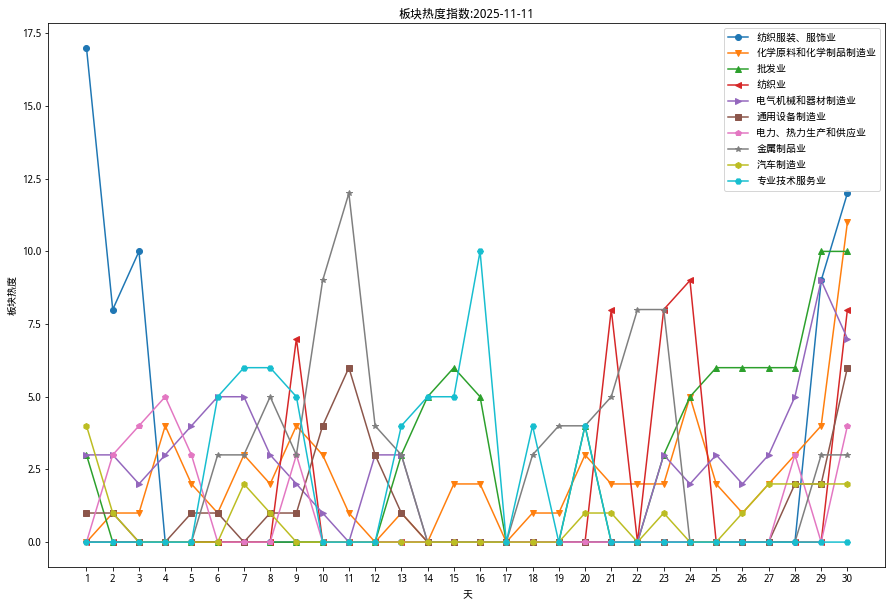

plot_industry_hot cost 0.5955360000000001 second
top_industry cost 5.810484000000001 second
stock_industry cost 0.7574550000000002 second
returns_series cost 1.008616 second


,score,top
sw_l2,,
特钢II,28,"[0/12]中信特钢:5.74%,久立特材:3.39%,方大特钢:1.52%,常宝股份:0.91%,金洲管道:0.28%"
电网设备II,20,"[0/118]柘中股份:19.63%,宏力达:17.23%,精达股份:15.8%,西典新能:14.79%,特锐德:13.98%"
电源设备II,19,"[1/26]海博思创:32.19%,上海电气:16.26%,金时科技:12.73%,英杰电气:8.68%,爱科赛博:8.49%"
医药商业II,17,"[0/31]浙江震元:6.43%,嘉事堂:3.61%,英特集团:0.18%,第一医药:0.14%,上海医药:0.06%"
电池II,16,"[1/93]华自科技:33.33%,鹏辉能源:18.56%,先导智能:17.79%,欣旺达:16.04%,芳源股份:15.09%"
工程机械II,11,"[0/28]拓山重工:12.18%,中际联合:4.95%,唯万密封:4.67%,中力股份:4.27%,海伦哲:4.17%"
其他电子II,11,"[0/31]京泉华:22.19%,沃尔核材:21.59%,太龙股份:15.93%,国力电子:8.48%,润欣科技:4.06%"
纺织制造II,11,"[0/30]迎丰股份:16.71%,富春染织:8.77%,欣龙控股:5.41%,联发股份:4.65%,宏达高科:2.91%"
服装家纺II,8,"[0/54]七匹狼:14.71%,棒杰股份:9.6%,洪兴股份:6.93%,天创时尚:3.52%,真爱美家:2.13%"


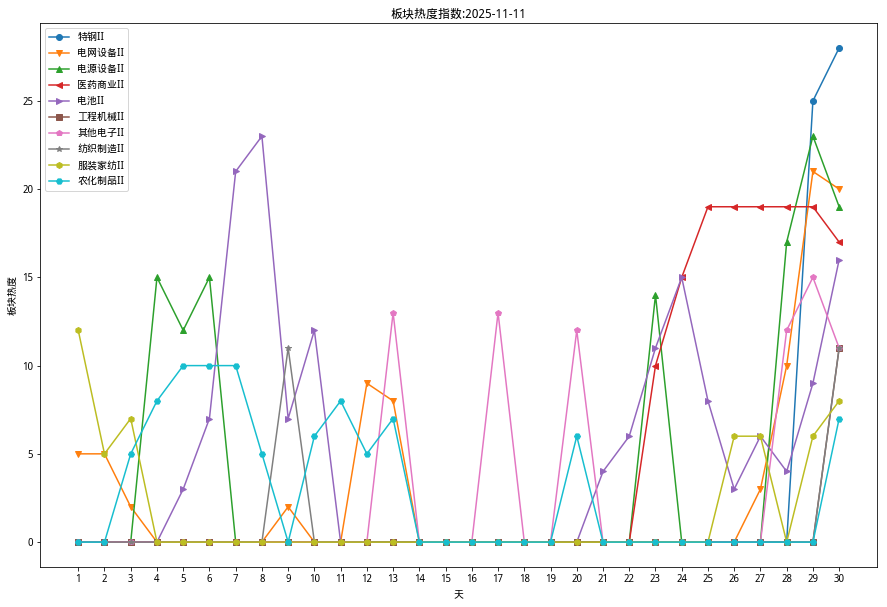

plot_industry_hot cost 0.5476100000000006 second
top_industry cost 4.7207349999999995 second
stock_industry cost 0.825921000000001 second
returns_series cost 0.9727050000000013 second


,score,top
jq_l2,,
输变电设备,41,"[0/17]平高电气:5.26%,望变电气:4.9%,长高电新:2.15%,中国西电:1.38%,保变电气:0.36%"
配电设备,37,"[0/30]柘中股份:19.63%,特锐德:13.98%,明阳电气:10.56%,百利电气:10.16%,科林电气:7.0%"
房屋建设,32,"[0/11]宁波建工:5.06%,空港股份:2.32%,中国中冶:1.19%,同济科技:-1.93%,中国建筑:-2.16%"
电池部件及材料,31,"[0/48]芳源股份:15.09%,西典新能:14.79%,中国宝安:12.84%,当升科技:11.21%,万润新能:9.47%"
水电,29,"[0/15]黔源电力:5.88%,华能水电:3.82%,桂冠电力:3.72%,南网储能:2.9%,广安爱众:1.87%"
节能与资源回收,28,"[0/30]凯美特气:19.46%,华新环保:6.79%,屹通新材:1.89%,海陆重工:1.49%,海新能科:1.36%"
特钢,24,"[0/14]武进不锈:14.07%,友发集团:8.26%,中信特钢:5.74%,久立特材:3.39%,物产金轮:1.87%"
污水处理,21,"[2/36]复洁环保:44.87%,倍杰特:31.63%,嘉戎技术:13.32%,中环环保:12.29%,中持股份:10.59%"
气液机械,17,"[0/37]联德股份:9.09%,东贝集团:8.71%,纽威股份:8.49%,恒工精密:6.12%,航天动力:5.88%"


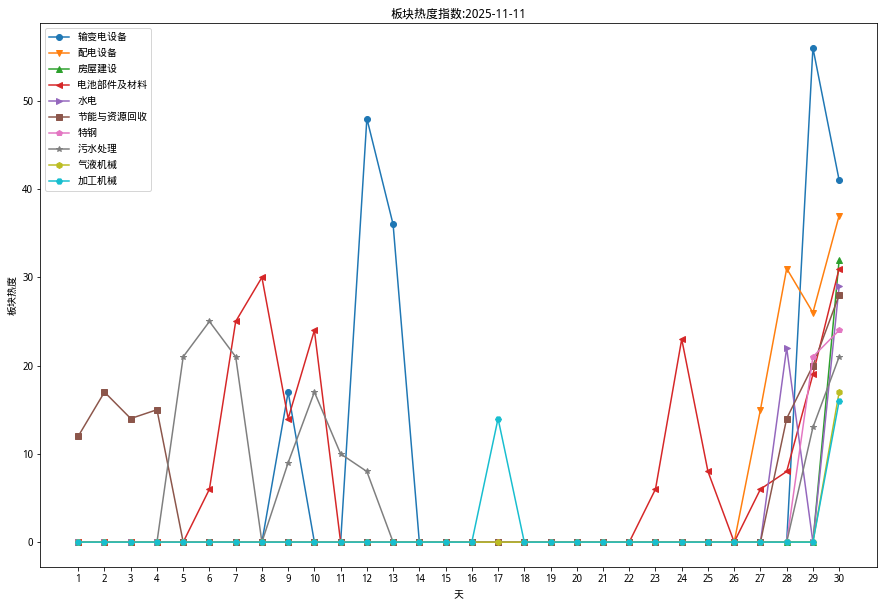

plot_industry_hot cost 0.5461150000000004 second
top_industry cost 6.904625000000001 second


In [ ]:
top_industry('2025-11-11','zjw',return_days=5,back_days=30,stock_top_count=5,industry_top_count=10,up_limit=30)
top_industry('2025-11-11','sw_l2',return_days=5,back_days=30,stock_top_count=5,industry_top_count=10,up_limit=30)
top_industry('2025-11-11','jq_l2',return_days=5,back_days=30,stock_top_count=5,industry_top_count=10,up_limit=30)